In [19]:
import pandas as pd 

E003 = pd.read_csv('benchmarks/randomforest/results/E003_bs_bf_para_indicators.csv')
E116 = pd.read_csv('benchmarks/randomforest/results/E116_bs_bf_para_indicators.csv')
E118 = pd.read_csv('benchmarks/randomforest/results/E118_bs_bf_para_indicators.csv')

burstformer_results = pd.read_csv('/Volumes/ExtremeSSD/BioStudy/CodeReview/burstformer/extra/datasets/benchmark/Promoterformer/results/bs_bf_para_indicators.csv')
burstformer_results['method'] = 'BurstFormer'
burstformer_results['auc'] = burstformer_results['auc'] / 100

data = pd.concat([E003, E116, E118,burstformer_results], axis=0).drop(columns=['acc'])
data


,eid,fold,target,method,auc
0,E003,1,bf_label,rf,0.924069
1,E003,1,bf_label,logit,0.913658
2,E003,1,bs_label,rf,0.720823
3,E003,1,bs_label,logit,0.705119
4,E003,2,bf_label,rf,0.924097
...,...,...,...,...,...
19,E003,1,bf_label,BurstFormer,0.936264
20,E003,2,bs_label,BurstFormer,0.761573
21,E003,2,bf_label,BurstFormer,0.936952
22,E003,3,bs_label,BurstFormer,0.726960


In [14]:
res = data.groupby(['eid', 'target','method'])['auc'].mean()
print(res)

eid   target    method     
E003  bf_label  BurstFormer    0.936326
                logit          0.909440
                rf             0.921017
      bs_label  BurstFormer    0.744319
                logit          0.707554
                rf             0.723903
E116  bf_label  BurstFormer    0.959085
                logit          0.940331
                rf             0.947941
      bs_label  BurstFormer    0.790122
                logit          0.753123
                rf             0.772151
E118  bf_label  BurstFormer    0.937828
                logit          0.909424
                rf             0.916966
      bs_label  BurstFormer    0.687274
                logit          0.633917
                rf             0.659359
Name: auc, dtype: float64


In [15]:

import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy import stats
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

In [16]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# sns.set_palette("colorblind")
# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_83846/3790649249.py:2: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(x='eid', y='auc', hue='method', data=data_bf,fliersize=1, palette=['#D55E00','#009E73','#0072B2','#E69F00'],width=0.6)


<Axes: xlabel='eid', ylabel='auc'>

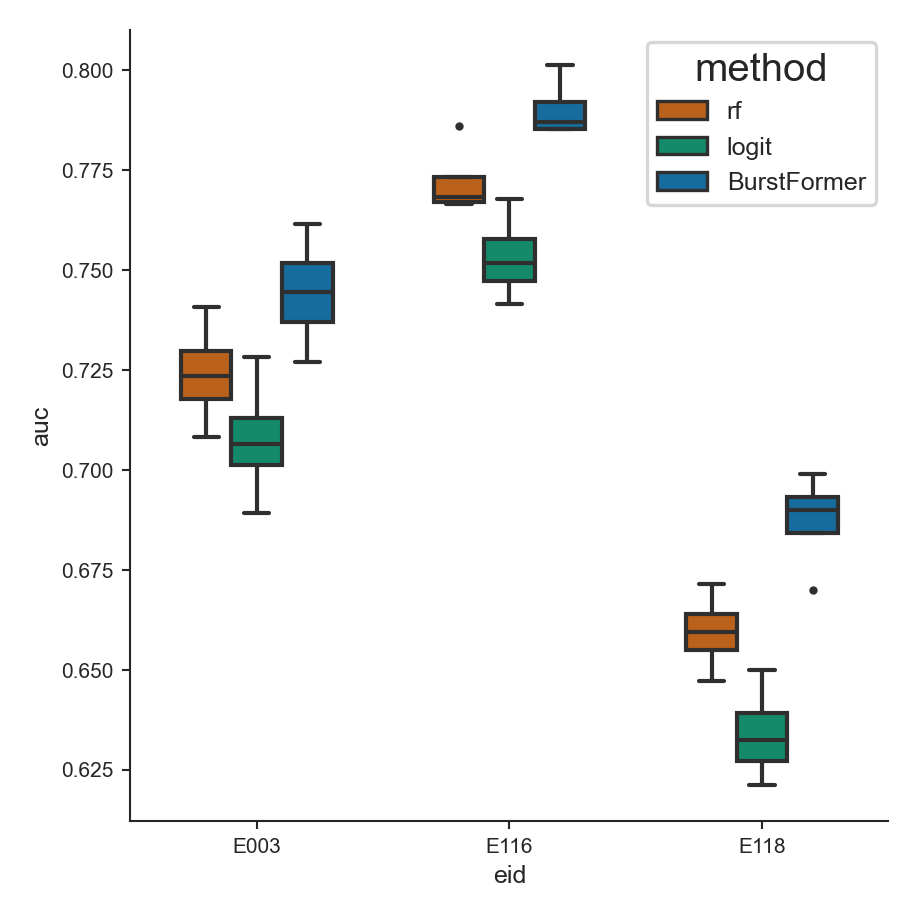

In [24]:
data_bf = data[data['target']=='bs_label']
sns.boxplot(x='eid', y='auc', hue='method', data=data_bf,fliersize=1, palette=['#D55E00','#009E73','#0072B2','#E69F00'],width=0.6)
